# 01. ML pipeline: train/test, CV, baseline i leakage

Ten notebook jest **brakującym fundamentem** przed blokiem liniowym i logistycznym.
Nie chodzi jeszcze o konkretny algorytm, tylko o sposób myślenia:

$$
\text{dane} \rightarrow \text{podział} \rightarrow \text{fit na train} \rightarrow \text{ocena na test}
$$

Po tej lekcji student powinien umieć odpowiedzieć na pytania:

1. Dlaczego nie oceniamy modelu na tych samych danych, na których go uczymy?
2. Co to jest baseline?
3. Co to jest cross-validation?
4. Dlaczego leakage potrafi dać „magicznie dobry” wynik?

## 1. Minimalny schemat pipeline'u

W każdym zadaniu ML trzeba jasno oddzielić trzy rzeczy:

- **cechy** $X$ — informacje dostępne przed predykcją,
- **target** $y$ — to, co chcemy przewidzieć,
- **metrykę** — sposób oceny jakości modelu.

Najprostszy pipeline:

$$
(X, y) \rightarrow (X_{train}, X_{test}, y_{train}, y_{test})
$$

$$
\text{model.fit}(X_{train}, y_{train})
$$

$$
\text{model.predict}(X_{test})
$$

Dydaktyczna intuicja: **test set ma udawać przyszłość**. Model nie powinien widzieć przyszłości podczas nauki.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

pd.set_option('display.precision', 4)
rng = np.random.default_rng(42)

## 2. Mały zbiór danych: nauka i wynik

Zrobimy syntetyczny zbiór przypominający prosty case edukacyjny.

Cechy:

- `StudyHours` — liczba godzin nauki,
- `Attendance` — obecność na zajęciach,
- `PreviousScore` — wcześniejszy wynik.

Targety:

- `Grade` — wynik punktowy, regresja,
- `Pass` — czy student zdał, klasyfikacja.

In [30]:
n = 90
study_hours = rng.uniform(0, 12, n)
attendance = rng.uniform(40, 100, n)
previous_score = rng.uniform(20, 95, n)
noise = rng.normal(0, 8, n)

grade = 25 + 4.2 * study_hours + 0.18 * attendance + 0.28 * previous_score + noise
grade = np.clip(grade, 0, 100)
pass_exam = (grade >= 60).astype(int)

df = pd.DataFrame({
    'StudyHours': study_hours,
    'Attendance': attendance,
    'PreviousScore': previous_score,
    'Grade': grade,
    'Pass': pass_exam
})

df.head()

,StudyHours,Attendance,PreviousScore,Grade,Pass
0,9.2875,49.1387,86.8094,95.0279,1
1,5.2665,81.7792,87.0085,88.0595,1
2,10.3032,66.7694,58.9144,92.3452,1
3,8.3684,62.8613,43.6947,87.4692,1
4,1.1301,58.0907,77.9009,70.1169,1


In [31]:
print(df[['Grade', 'Pass']].describe())
print('\nLiczba zdanych / niezdanych:')
print(df['Pass'].value_counts().rename(index={0:'Fail', 1:'Pass'}))

          Grade     Pass
count   90.0000  90.0000
mean    77.8226   0.8111
std     16.8048   0.3936
min     38.7956   0.0000
25%     68.6136   1.0000
50%     80.3506   1.0000
75%     91.1898   1.0000
max    100.0000   1.0000

Liczba zdanych / niezdanych:
Pass    73
Fail    17
Name: Pass, dtype: int64


# 3. Podział train/test

Najprostszy podział:

$$
\text{train} = 75\%, \quad \text{test} = 25\%
$$

Uwaga dydaktyczna: podział robimy **przed** treningiem i przed oceną. Jeżeli skalujemy, imputujemy braki albo wybieramy cechy, to te operacje też powinny być uczone tylko na train.

In [32]:
features = ['StudyHours', 'Attendance', 'PreviousScore']
X = df[features]
y_reg = df['Grade']
y_cls = df['Pass']

X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.25, random_state=7, stratify=y_cls
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (67, 3) Test: (23, 3)


## 4. Baseline w regresji

Baseline to prosty punkt odniesienia. Dla regresji naturalny baseline to przewidywanie średniej z treningu:

$$
\hat y_i = \bar y_{train}
$$

Model ma sens dopiero wtedy, gdy bije taki naiwny punkt odniesienia.

In [33]:
# Baseline: zawsze przewiduj średnią z y_train
baseline_pred = np.repeat(y_train_reg.mean(), len(y_test_reg))

# Model liniowy
lin = LinearRegression()
lin.fit(X_train, y_train_reg)
lin_pred = lin.predict(X_test)

results_reg = pd.DataFrame({
    'model': ['baseline_mean', 'linear_regression'],
    'MAE': [mean_absolute_error(y_test_reg, baseline_pred), mean_absolute_error(y_test_reg, lin_pred)],
    'RMSE': [mean_squared_error(y_test_reg, baseline_pred) ** 0.5, mean_squared_error(y_test_reg, lin_pred) ** 0.5],
    'R2': [r2_score(y_test_reg, baseline_pred), r2_score(y_test_reg, lin_pred)]
})
results_reg

,model,MAE,RMSE,R2
0,baseline_mean,14.8367,17.7563,-0.0066
1,linear_regression,6.8644,8.4217,0.7736


Interpretacja:

- `MAE` mówi: średnio o ile punktów się mylimy.
- `RMSE` mocniej karze duże błędy.
- $R^2$ mówi, ile zmienności targetu wyjaśnia model względem baseline'u średniej:

$$
R^2 = 1 - \frac{SSE_{model}}{SSE_{baseline}}
$$

## 5. Baseline w klasyfikacji

Dla klasyfikacji prosty baseline to przewidywanie najczęstszej klasy.

Jeśli większość studentów zdała, baseline mówi zawsze: „zdał”.

In [34]:
majority_class = int(y_train_cls.mode()[0])
baseline_cls_pred = np.repeat(majority_class, len(y_test_cls))

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train_cls)
proba = logreg.predict_proba(X_test)[:, 1]
pred_cls = (proba >= 0.5).astype(int)

results_cls = pd.DataFrame({
    'model': ['baseline_majority', 'logistic_regression'],
    'accuracy': [accuracy_score(y_test_cls, baseline_cls_pred), accuracy_score(y_test_cls, pred_cls)],
    'AUC': [np.nan, roc_auc_score(y_test_cls, proba)]
})
results_cls

,model,accuracy,AUC
0,baseline_majority,0.8261,NaN
1,logistic_regression,0.8696,0.9079


In [35]:
cm = confusion_matrix(y_test_cls, pred_cls)
pd.DataFrame(cm, index=['actual_0_fail', 'actual_1_pass'], columns=['pred_0_fail', 'pred_1_pass'])

,pred_0_fail,pred_1_pass
actual_0_fail,2,2
actual_1_pass,1,18


## 6. Cross-validation

Jeden podział train/test może być pechowy. Cross-validation powtarza eksperyment na kilku podziałach.

Dla $K=5$:

$$
\text{wynik CV} = \frac{1}{5}\sum_{k=1}^{5} score_k
$$

Intuicja: każdy fragment danych raz udaje test, a kilka razy udaje train.

In [36]:
# Tworzymy obiekt KFold do walidacji krzyżowej (cross-validation)
kfold = KFold(
    n_splits=5,        # dzielimy dane na 5 części (foldów)
    shuffle=True,      # mieszamy dane przed podziałem
    random_state=123   # ustawiamy seed losowości -> wynik będzie powtarzalny
)

# cross_val_score:
# 1. bierze model (LinearRegression)
# 2. wielokrotnie trenuje go na części danych
# 3. testuje na pozostałej części
# 4. zwraca wynik dla każdego foldu
cv_scores = cross_val_score(
    LinearRegression(), # model regresji liniowej
    X,                   # cechy wejściowe
    y_reg,               # wartości docelowe
    cv=kfold,            # sposób podziału danych (nasz KFold)
    scoring='r2'         # metryka jakości -> współczynnik R²
)

# Wyniki R² dla każdego z 5 foldów
print('R2 w foldach:', np.round(cv_scores, 3))

# Średni wynik modelu
print('Średnie R2:', round(cv_scores.mean(), 3))

# Odchylenie standardowe wyników
# pokazuje stabilność modelu między foldami
print('Odchylenie:', round(cv_scores.std(), 3))

R2 w foldach: [0.822 0.688 0.701 0.873 0.745]
Średnie R2: 0.766
Odchylenie: 0.071


## Współczynnik determinacji $R^2$

Współczynnik $R^2$ mówi nam, jak dobrze model wyjaśnia zmienność danych.

Porównujemy:

- błąd modelu,
- z błędem bardzo prostego modelu bazowego przewidującego tylko średnią.

Definicja:

$$
R^2 = 1 - \frac{SSE}{TSS}
$$

gdzie:

$$
SSE = \sum_i (y_i - \hat{y}_i)^2
$$

to suma kwadratów błędów modelu,

natomiast:

$$
TSS = \sum_i (y_i - \bar{y})^2
$$

to całkowita zmienność danych względem średniej.

---

Interpretacja:

- $R^2 = 1$
  
  model idealny,
  wszystkie punkty leżą dokładnie na przewidywaniach.

- $R^2 = 0$
  
  model nie jest lepszy niż zgadywanie średniej.

- $R^2 < 0$
  
  model działa gorzej niż przewidywanie samej średniej.

---

Intuicyjnie:

$$
R^2
$$

mierzy, jaką część zmienności danych udało się wyjaśnić modelowi.

Przykład:

$$
R^2 = 0.85
$$

oznacza, że model wyjaśnia około $85\%$ zmienności danych.


- $\bar{y}$ to średnia wszystkich wartości w danych:

$$
\bar{y} = \frac{1}{n}\sum_i y_i
$$

- $\hat{y}_i$ to przewidywanie modelu dla konkretnego punktu $x_i$:

$$
\hat{y}_i = b_0 + b_1 x_i
$$

- $\bar{y}$ odpowiada modelowi „zgaduję zawsze średnią”.  
- $\hat{y}_i$ wykorzystuje zależność między $x$ i $y$.  

- $\bar{y}$ to średnia wszystkich wartości w danych — jedna stała liczba.  
- $\hat{y}_i$ to przewidywanie modelu dla konkretnego punktu $x_i$.  
- $\bar{y}$ odpowiada modelowi „zgaduję zawsze średnią”.  
- $\hat{y}_i$ wykorzystuje zależność między $x$ i $y$.  

## 7. Leakage: kiedy model zna odpowiedź z przyszłości

**Leakage** występuje wtedy, gdy do cech trafi informacja, której nie mielibyśmy w momencie predykcji.

Przykład skrajny: chcemy przewidzieć `Pass`, ale dodajemy cechę prawie równą `Grade`.

Formalnie model widzi wtedy coś bardzo bliskiego targetowi:

$$
X_{leak} \approx y
$$

Wynik testowy wygląda świetnie, ale taki model jest bezużyteczny w realnym użyciu.

In [37]:
df_leak = df.copy()
df_leak['GradeAfterExam_LEAK'] = df_leak['Grade'] + rng.normal(0, 1, len(df_leak))

X_honest = df_leak[['StudyHours', 'Attendance', 'PreviousScore']]
X_leaky = df_leak[['StudyHours', 'Attendance', 'PreviousScore', 'GradeAfterExam_LEAK']]
y = df_leak['Pass']

Xh_train, Xh_test, Xl_train, Xl_test, yh_train, yh_test = train_test_split(
    X_honest, X_leaky, y, test_size=0.25, random_state=11, stratify=y
)

model_honest = LogisticRegression(max_iter=1000).fit(Xh_train, yh_train)
model_leaky = LogisticRegression(max_iter=1000).fit(Xl_train, yh_train)

auc_honest = roc_auc_score(yh_test, model_honest.predict_proba(Xh_test)[:, 1])
auc_leaky = roc_auc_score(yh_test, model_leaky.predict_proba(Xl_test)[:, 1])

pd.DataFrame({
    'model': ['uczciwy_model', 'model_z_leakage'],
    'AUC_test': [auc_honest, auc_leaky]
})

,model,AUC_test
0,uczciwy_model,0.8421
1,model_z_leakage,0.9605


### Komentarz do prowadzenia

Wysokie AUC modelu z leakage nie oznacza, że model jest mądry. Oznacza, że w danych pojawiła się informacja, której nie wolno użyć.

Pytanie kontrolne dla studentów:

> Czy ta cecha byłaby znana w chwili, gdy model ma podjąć decyzję?

Jeśli odpowiedź brzmi „nie”, prawdopodobnie mamy leakage.

## 8. Checklista pipeline'u

Przed każdym modelem sprawdź:

1. Co jest targetem $y$?
2. Jakie cechy są dostępne przed predykcją?
3. Jaki jest baseline?
4. Jaki mamy podział train/test albo CV?
5. Jaką metrykę optymalizujemy?
6. Czy żadna cecha nie przecieka z targetu?
7. Czy wynik jest stabilny na kilku podziałach?

## Proste ćwiczenia

1. Wskaż baseline dla regresji i klasyfikacji w tym notebooku.
2. Dlaczego model z `GradeAfterExam_LEAK` ma bardzo dobre AUC?
3. Co może pójść źle, jeśli wybierzemy cechy na całym zbiorze przed podziałem train/test?
4. Zmień `test_size` z `0.25` na `0.4`. Czy wyniki są identyczne?

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/previous_lecture_grades.csv")

df.head()

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0


In [39]:
data = df.dropna(subset=["StudyHours", "Grade"]).copy()

print("Liczba obserwacji przed czyszczeniem:", len(df))
print("Liczba obserwacji po czyszczeniu:", len(data))

data.head()

Liczba obserwacji przed czyszczeniem: 24
Liczba obserwacji po czyszczeniu: 22


,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0


In [40]:
PASS_LIMIT = 50

data["Passed"] = data["Grade"] >= PASS_LIMIT

data[["Name", "StudyHours", "Grade", "Passed"]].head()

,Name,StudyHours,Grade,Passed
0,Dan,10.00,50.0,True
1,Joann,11.50,50.0,True
2,Pedro,9.00,47.0,False
3,Rosie,16.00,97.0,True
4,Ethan,9.25,49.0,False


In [41]:
data["Passed"].value_counts()

True     11
False    11
Name: Passed, dtype: int64

In [42]:
HOURS_LIMIT = 10

data["HighHours"] = data["StudyHours"] >= HOURS_LIMIT

table = pd.crosstab(data["HighHours"], data["Passed"])
table

Passed,False,True
HighHours,,
False,10,0
True,1,11


In [43]:
# liczby z tabeli
passed_high = table.loc[True, True]
failed_high = table.loc[True, False]

passed_low = table.loc[False, True]
failed_low = table.loc[False, False]

# korekta, żeby uniknąć dzielenia przez zero
correction = 0.5

odds_plus = (passed_high + correction) / (failed_high + correction)
odds_minus = (passed_low + correction) / (failed_low + correction)

OR = odds_plus / odds_minus
log_OR = np.log(OR)

print(f"odds(+)  = {odds_plus:.3f}")
print(f"odds(-)  = {odds_minus:.3f}")
print(f"OR       = {OR:.3f}")
print(f"log(OR)  = {log_OR:.3f}")

odds(+)  = 7.667
odds(-)  = 0.048
OR       = 161.000
log(OR)  = 5.081


In [44]:
thresholds = [6, 8, 9, 10, 11.5, 12, 13, 14, 15]

results = []

for threshold in thresholds:
    high_hours = data["StudyHours"] >= threshold
    passed = data["Passed"]

    passed_high = ((high_hours == True) & (passed == True)).sum()
    failed_high = ((high_hours == True) & (passed == False)).sum()

    passed_low = ((high_hours == False) & (passed == True)).sum()
    failed_low = ((high_hours == False) & (passed == False)).sum()

    # korekta 0.5, żeby uniknąć dzielenia przez zero
    odds_plus = (passed_high + 0.5) / (failed_high + 0.5)
    odds_minus = (passed_low + 0.5) / (failed_low + 0.5)

    OR = odds_plus / odds_minus
    log_OR = np.log(OR)

    results.append({
        "threshold": threshold,
        "passed_high": passed_high,
        "failed_high": failed_high,
        "passed_low": passed_low,
        "failed_low": failed_low,
        "odds(+)": odds_plus,
        "odds(-)": odds_minus,
        "OR": OR,
        "log(OR)": log_OR
    })

or_table = pd.DataFrame(results)

or_table

,threshold,passed_high,failed_high,passed_low,failed_low,odds(+),odds(-),OR,log(OR)
0,6.0,11,10,0,1,1.0952,0.3333,3.2857,1.1896
1,8.0,11,9,0,2,1.2105,0.2000,6.0526,1.8005
2,9.0,11,6,0,5,1.7692,0.0909,19.4615,2.9684
3,10.0,11,1,0,10,7.6667,0.0476,161.0000,5.0814
4,11.5,10,0,1,11,21.0000,0.1304,161.0000,5.0814
5,12.0,8,0,3,11,17.0000,0.3043,55.8571,4.0228
6,13.0,5,0,6,11,11.0000,0.5652,19.4615,2.9684
7,14.0,4,0,7,11,9.0000,0.6522,13.8000,2.6247
8,15.0,3,0,8,11,7.0000,0.7391,9.4706,2.2482


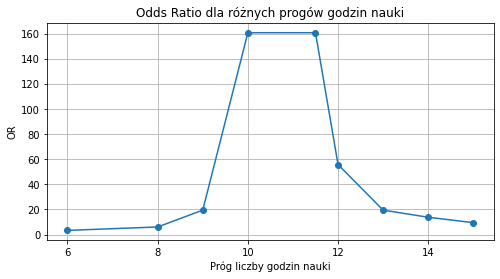

In [45]:
plt.figure(figsize=(8, 4))
plt.plot(or_table["threshold"], or_table["OR"], marker="o")
plt.xlabel("Próg liczby godzin nauki")
plt.ylabel("OR")
plt.title("Odds Ratio dla różnych progów godzin nauki")
plt.grid(True)
plt.show()

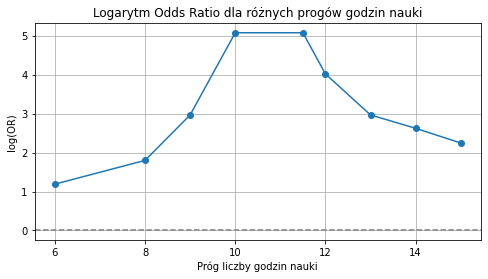

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(or_table["threshold"], or_table["log(OR)"], marker="o")
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Próg liczby godzin nauki")
plt.ylabel("log(OR)")
plt.title("Logarytm Odds Ratio dla różnych progów godzin nauki")
plt.grid(True)
plt.show()

In [47]:
OR_values = np.array([1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16])
log_OR_values = np.log(OR_values)

print("OR\t\tlog(OR)")
for or_val, log_val in zip(OR_values, log_OR_values):
    print(f"{or_val:.4f}\t\t{log_val:.3f}")

OR		log(OR)
0.0625		-2.773
0.1250		-2.079
0.2500		-1.386
0.5000		-0.693
1.0000		0.000
2.0000		0.693
4.0000		1.386
8.0000		2.079
16.0000		2.773


In [48]:
from sklearn.linear_model import LogisticRegression

X = data[["StudyHours"]]
y = data["Passed"].astype(int)

model = LogisticRegression()
model.fit(X, y)

beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]

print(f"beta_0 = {beta_0:.3f}")
print(f"beta_1 = {beta_1:.3f}")
print(f"exp(beta_1) = {np.exp(beta_1):.3f}")

beta_0 = -16.102
beta_1 = 1.559
exp(beta_1) = 4.752


In [49]:
hours_grid = np.array([6, 8, 10, 12, 14, 16])

summary = []

for h in hours_grid:
    log_odds = beta_0 + beta_1 * h
    odds = np.exp(log_odds)
    probability = odds / (1 + odds)

    summary.append({
        "StudyHours": h,
        "probability": probability,
        "odds": odds,
        "log_odds": log_odds
    })

summary_df = pd.DataFrame(summary)

summary_df

,StudyHours,probability,odds,log_odds
0,6,0.0012,0.0012,-6.7509
1,8,0.0257,0.0264,-3.6338
2,10,0.3736,0.5965,-0.5166
3,12,0.9309,13.4703,2.6005
4,14,0.9967,304.1812,5.7176
5,16,0.9999,6868.8909,8.8348
